# Análisis y Estudio de Dataset de Cáncer de Mama

Alberto Palma Alfaro

Proyecto Final Data Science Parte II Coderhouse

## Abstract y Contexto

Este análisis se basa en un conjunto de datos relacionado con imágenes digitalizadas de biopsias de punción aspiracion con aguja fina (FNA) de masas mamarias.

El dataset contiene 569 observaciones con 30 variables numéricas que representan medidas estadísticas (media, error estándar y valores extremos) de atributos como radio, textura, perímetro, área, concavidad, entre otros, además de una columna de diagnóstico (benigno o maligno).

## Hipótesis

1. Los tumores malignos presentan mayores valores promedio de radio, área y perímetro que los benignos.
2. La variable `concavity_worst` es un buen predictor para diferenciar entre tipos de tumor.
3. La textura media podría no variar significativamente entre tumores benignos y malignos.

## Objetivo

El objetivo principal es estudiar las características que permiten distinguir entre tumores malignos y benignos, de manera de predecir con herramientas de machine learning dicho diagnóstico.

# Lectura de Datos

In [2]:
# Importación de librerías

# Gráficos con librería matplotlib
import matplotlib.pyplot as plt

# Gráficos con librería Seaborn
import seaborn as sns

# Carga de CSV de GitHub
import pandas as pd
url= 'https://raw.githubusercontent.com/virusvetro/Pandas/refs/heads/main/breast-cancer.csv'

# Importación de datos
df = pd.read_csv(url)

# Vista general
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# Cantidad de filas y columnas
df.shape

(569, 32)

In [4]:
# Info general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

## Descripción de las variables del dataset

- **id**: Identificador único para cada paciente.
- **diagnosis**: Diagnóstico del tumor (M = maligno, B = benigno).
- **radius_mean**: Promedio del radio del tumor.
- **texture_mean**: Promedio de la textura del tumor.
- **perimeter_mean**: Promedio del perímetro del tumor.
- **area_mean**: Promedio del área del tumor.
- **smoothness_mean**: Promedio de la suavidad del tumor.
- **compactness_mean**: Promedio de la compacidad del tumor.
- **concavity_mean**: Promedio de la concavidad del tumor.
- **concave points_mean**: Promedio de los puntos cóncavos del tumor.
- **symmetry_mean**: Promedio de la simetría del tumor.
- **fractal_dimension_mean**: Promedio de la dimensión fractal del tumor.
- **radius_se**: Error estándar del radio del tumor.
- **texture_se**: Error estándar de la textura del tumor.
- **perimeter_se**: Error estándar del perímetro del tumor.
- **area_se**: Error estándar del área del tumor.
- **smoothness_se**: Error estándar de la suavidad del tumor.
- **compactness_se**: Error estándar de la compacidad del tumor.
- **concavity_se**: Error estándar de la concavidad del tumor.
- **concave points_se**: Error estándar de los puntos cóncavos del tumor.
- **symmetry_se**: Error estándar de la simetría del tumor.
- **fractal_dimension_se**: Error estándar de la dimensión fractal del tumor.
- **radius_worst**: Valor más alto (peor) del radio del tumor.
- **texture_worst**: Valor más alto (peor) de la textura del tumor.
- **perimeter_worst**: Valor más alto (peor) del perímetro del tumor.
- **area_worst**: Valor más alto (peor) del área del tumor.
- **smoothness_worst**: Valor más alto (peor) de la suavidad del tumor.
- **compactness_worst**: Valor más alto (peor) de la compacidad del tumor.
- **concavity_worst**: Valor más alto (peor) de la concavidad del tumor.
- **concave points_worst**: Valor más alto (peor) de los puntos cóncavos del tumor.
- **symmetry_worst**: Valor más alto (peor) de la simetría del tumor.
- **fractal_dimension_worst**: Valor más alto (peor) de la dimensión fractal del tumor.

# Data Wrangling - Limpieza y transformación de datos

## Datos Nulos

In [5]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


## Tratamiento de valores outliers

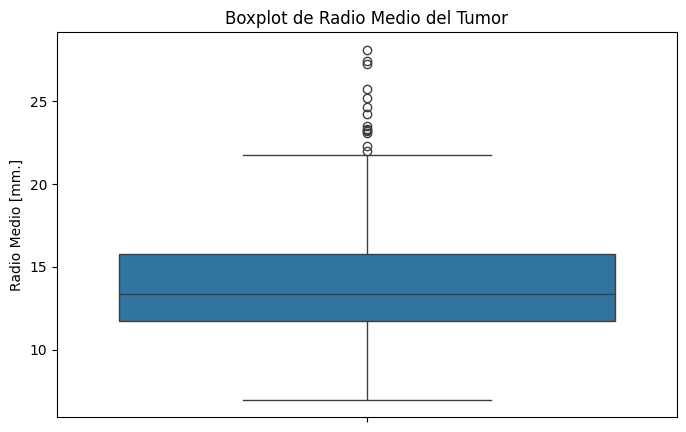

In [6]:
# Creación del boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df['radius_mean'])
plt.title("Boxplot de Radio Medio del Tumor")
plt.ylabel("Radio Medio [mm.]")
plt.show()

In [7]:
# Calcular el IQR

Q1 = df['radius_mean'].quantile(0.25)
Q3 = df['radius_mean'].quantile(0.75)
IQR = Q3 - Q1

# Definir límites
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identificar outliers
outliers_iqr = df[(df['radius_mean'] < lower_bound) | (df['radius_mean'] > upper_bound)]

outliers_iqr

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
82,8611555,M,25.22,24.91,171.5,1878.0,0.10630,0.2665,0.3339,0.18450,...,30.00,33.62,211.7,2562.0,0.1573,0.6076,0.6476,0.2867,0.2355,0.10510
108,86355,M,22.27,19.67,152.8,1509.0,0.13260,0.2768,0.4264,0.18230,...,28.40,28.01,206.8,2360.0,0.1701,0.6997,0.9608,0.2910,0.4055,0.09789
122,865423,M,24.25,20.20,166.2,1761.0,0.14470,0.2867,0.4268,0.20120,...,26.02,23.99,180.9,2073.0,0.1696,0.4244,0.5803,0.2248,0.3222,0.08009
164,8712289,M,23.27,22.04,152.1,1686.0,0.08439,0.1145,0.1324,0.09702,...,28.01,28.22,184.2,2403.0,0.1228,0.3583,0.3948,0.2346,0.3589,0.09187
180,873592,M,27.22,21.87,182.1,2250.0,0.10940,0.1914,0.2871,0.18780,...,33.12,32.85,220.8,3216.0,0.1472,0.4034,0.5340,0.2688,0.2856,0.08082
202,878796,M,23.29,26.67,158.9,1685.0,0.11410,0.2084,0.3523,0.16200,...,25.12,32.68,177.0,1986.0,0.1536,0.4167,0.7892,0.2733,0.3198,0.08762
212,8810703,M,28.11,18.47,188.5,2499.0,0.11420,0.1516,0.3201,0.15950,...,28.11,18.47,188.5,2499.0,0.1142,0.1516,0.3201,0.1595,0.1648,0.05525
236,88299702,M,23.21,26.97,153.5,1670.0,0.09509,0.1682,0.1950,0.12370,...,31.01,34.51,206.0,2944.0,0.1481,0.4126,0.5820,0.2593,0.3103,0.08677
339,89812,M,23.51,24.27,155.1,1747.0,0.10690,0.1283,0.2308,0.14100,...,30.67,30.73,202.4,2906.0,0.1515,0.2678,0.4819,0.2089,0.2593,0.07738
352,899987,M,25.73,17.46,174.2,2010.0,0.11490,0.2363,0.3368,0.19130,...,33.13,23.58,229.3,3234.0,0.1530,0.5937,0.6451,0.2756,0.3690,0.08815


Dada la naturaleza del estudio, si se considerarán dentro del análisis dichas muestras con valores outliers ya que el radio de dichos tumores no es exageradamente grande, por lo que si representa un valor plausible cuyo análisis obtenido si será cercano a la realidad.

# Análisis Exploratorio de Datos (EDA)

In [8]:
# Tabla resumen de estadísticas
df.describe().T


,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


<Figure size 800x500 with 0 Axes>

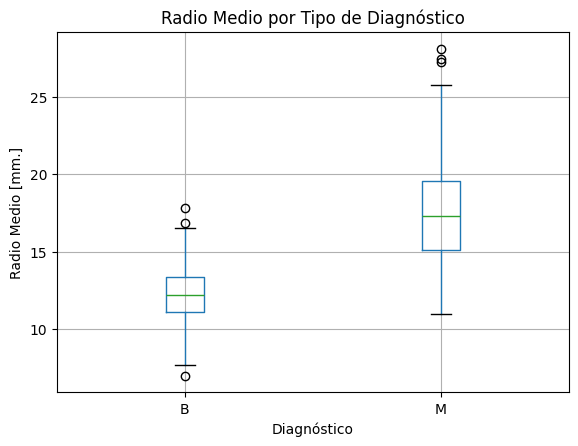

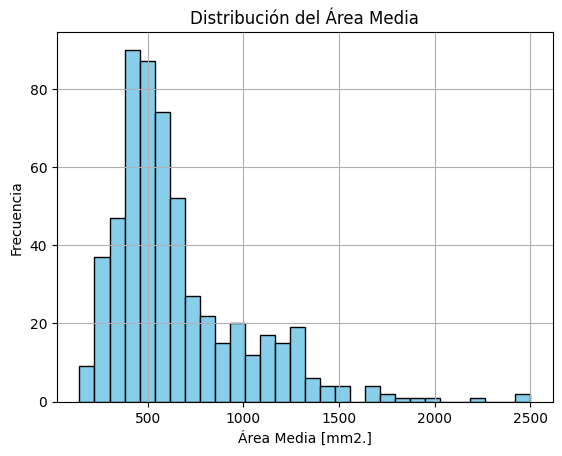

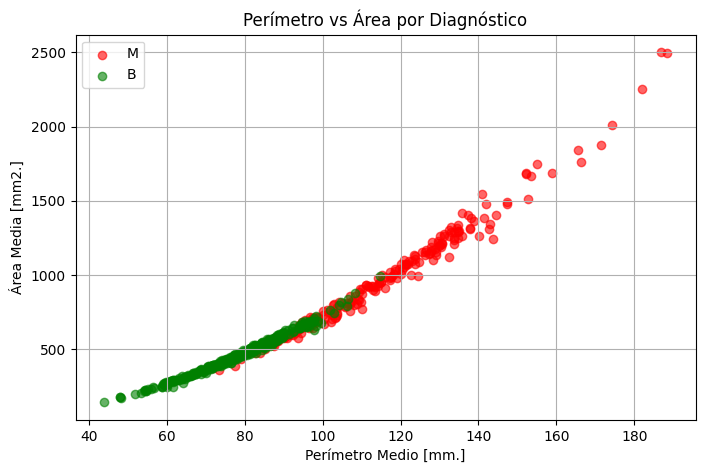

In [9]:
# Gráficos con librería matplotlib

# Comparación de radio medio por diagnóstico
plt.figure(figsize=(8, 5))
df.boxplot(column='radius_mean', by='diagnosis', grid=True)
plt.title('Radio Medio por Tipo de Diagnóstico')
plt.suptitle('')
plt.xlabel('Diagnóstico')
plt.ylabel('Radio Medio [mm.]')
plt.show()

# Histograma del área media
plt.hist(df['area_mean'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribución del Área Media')
plt.xlabel('Área Media [mm2.]')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

# Gráfico de dispersión entre perímetro y área
colors = {'M': 'red', 'B': 'green'}
plt.figure(figsize=(8, 5))
for diag in df['diagnosis'].unique():
    subset = df[df['diagnosis'] == diag]
    plt.scatter(subset['perimeter_mean'], subset['area_mean'],
                label=diag, alpha=0.6, c=colors[diag])
plt.xlabel('Perímetro Medio [mm.]')
plt.ylabel('Área Media [mm2.]')
plt.title('Perímetro vs Área por Diagnóstico')
plt.legend()
plt.grid(True)
plt.show()


/tmp/ipython-input-1394226835.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='diagnosis', y='concavity_worst', data=df, palette='Set2')


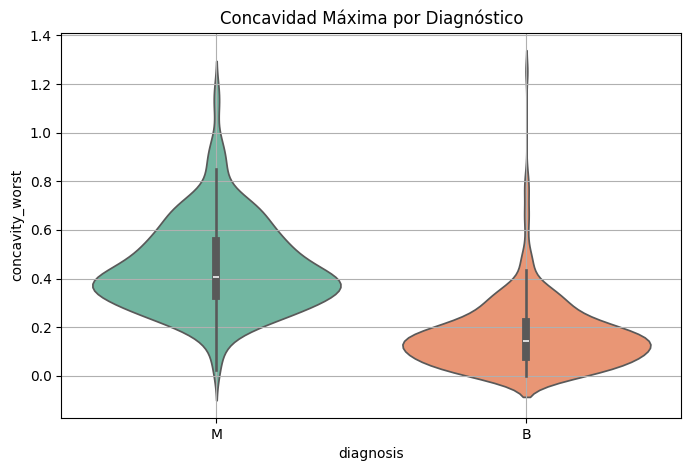

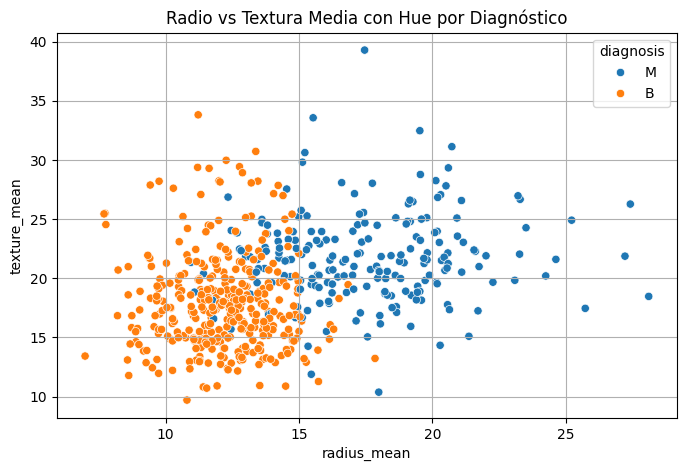

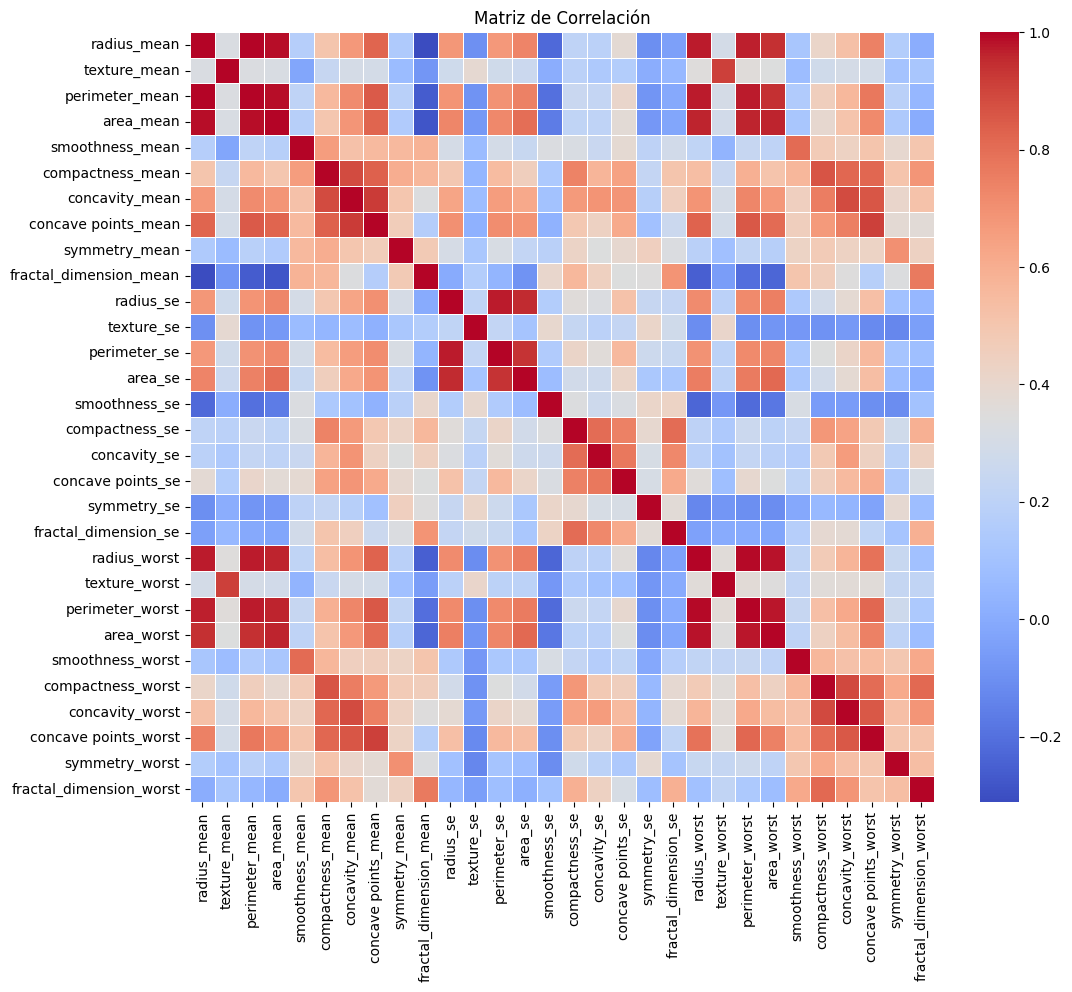

In [10]:
# Gráficos con librería Seaborn

# Gráfico de violín
plt.figure(figsize=(8, 5))
sns.violinplot(x='diagnosis', y='concavity_worst', data=df, palette='Set2')
plt.title('Concavidad Máxima por Diagnóstico')
plt.grid(True)
plt.show()

# Gráfico de dispersión con hue
plt.figure(figsize=(8, 5))
sns.scatterplot(x='radius_mean', y='texture_mean', hue='diagnosis', data=df)
plt.title('Radio vs Textura Media con Hue por Diagnóstico')
plt.grid(True)
plt.show()

# Heatmap de correlación
plt.figure(figsize=(12, 10))
corr = df.iloc[:, 2:].corr()
sns.heatmap(corr, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()


## Interpretación de Gráficos

- **Boxplot de radio medio**: Los tumores malignos tienden a tener un radio significativamente mayor que los benignos, por lo que efectivamente los tumores malignos presentan mayores valores promedio de radio, como lo postulado en la hipótesis 1.
- **Histograma de área media**: La distribución es asimétrica, con valores extremos en el lado derecho del gráfico que corresponden principalmente a tumores malignos.
- **Dispersión perímetro vs área**: Existe una correlación visible entre estas dos variables, donde los tumores malignos suelen concentrarse en valores más altos, reforzando la hipótesis 1, ya que efectivamente los tumores malignos presentan mayores valores de área y perímetro que los benignos.
- **Violinplot de concavidad**: Se observa una clara diferencia entre tipos de diagnóstico, reforzando la hipótesis 2, de que la variable concavity_worst es un buen predictor para diferenciar entre tipos de tumor.
- **Scatterplot radio vs textura**: No se observa una clara separación por diagnóstico en cuanto a la textura, lo que podría apoyar la hipótesis 3, sin embargo se necesita una prueba estadística para más certeza.
- **Heatmap de correlaciones**: Hay una alta correlación entre medidas como radio, área y perímetro, lo que indica redundancia en las variables.




## Insights Adicionales

Estos insights se centran en distribuciones, comparaciones estadísticas y pruebas de hipótesis, para profundizar en el análisis de las características de los tumores.

##  Insight 1: Distribución de Diagnósticos

Este insight muestra la proporción de tumores benignos (B) y malignos (M). Ayuda a entender el balance del dataset.

/tmp/ipython-input-891115345.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette='Set2')


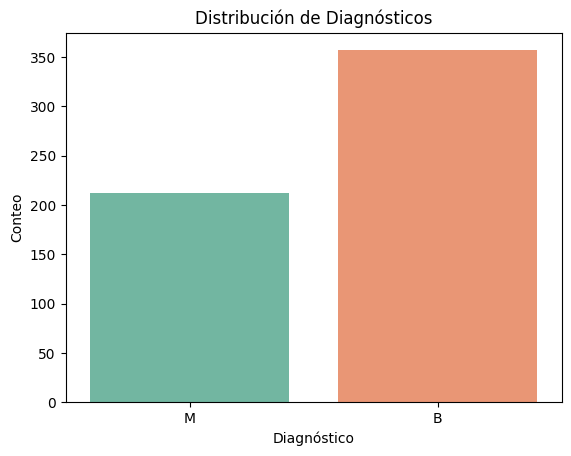

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='diagnosis', data=df, palette='Set2')
plt.title('Distribución de Diagnósticos')
plt.xlabel('Diagnóstico')
plt.ylabel('Conteo')
plt.show()

## Insight 2: Comparación de Medias por Grupo

Este insight presenta una tabla con las medias de variables clave (radio, área, perímetro, concavidad máxima y textura) agrupadas por diagnóstico, destacando diferencias entre benignos y malignos.

           radius_mean  perimeter_mean  texture_mean
diagnosis                                           
B            12.146524       78.075406     17.914762
M            17.462830      115.365377     21.604906
diagnosis
B    462.790196
M    978.376415
Name: area_mean, dtype: float64
diagnosis
B    0.166238
M    0.450606
Name: concavity_worst, dtype: float64


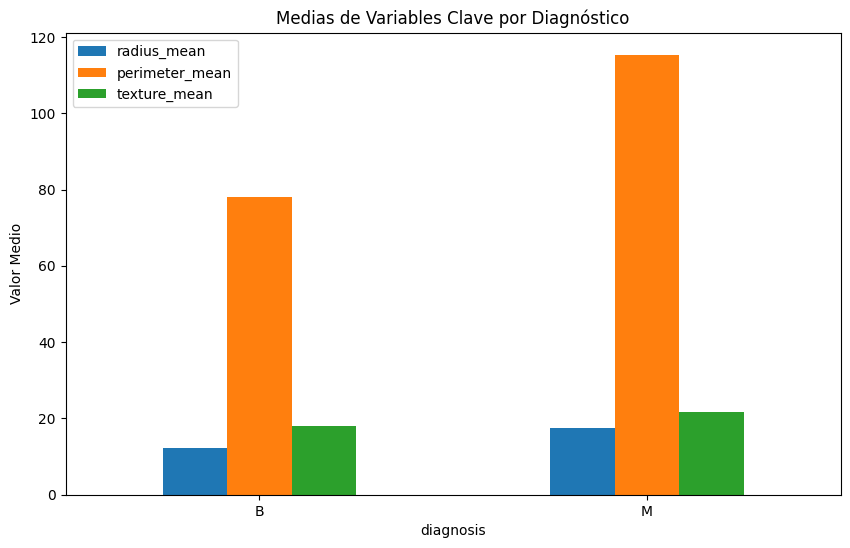

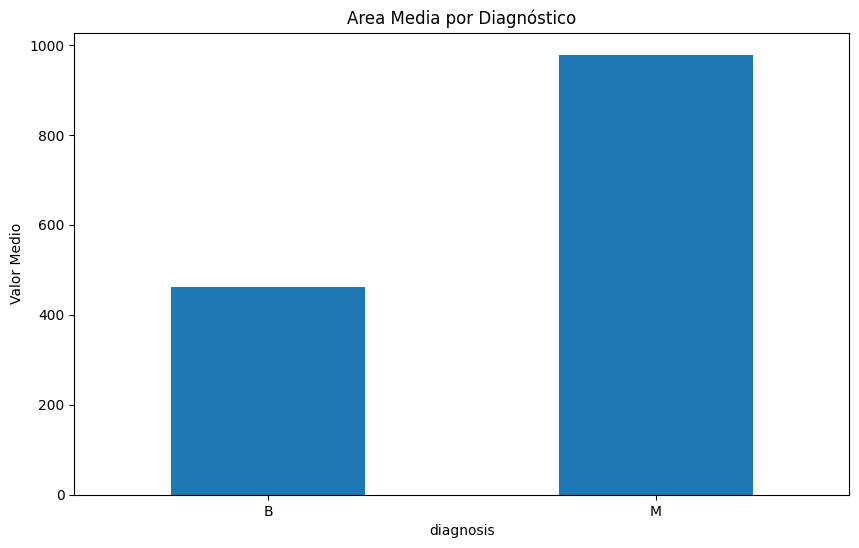

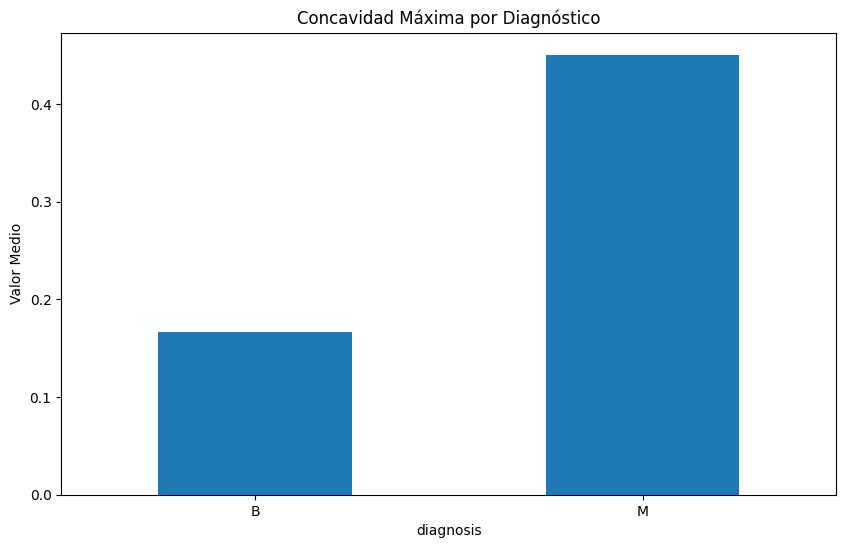

In [12]:
means1 = df.groupby('diagnosis')[['radius_mean', 'perimeter_mean', 'texture_mean']].mean()
print(means1)

means2 = df.groupby('diagnosis')['area_mean'].mean()
print(means2)

means3 = df.groupby('diagnosis')['concavity_worst'].mean()
print(means3)

# Visualización como histograma
means1.plot(kind='bar', figsize=(10, 6))
plt.title('Medias de Variables Clave por Diagnóstico')
plt.ylabel('Valor Medio')
plt.xticks(rotation=0)
plt.show()

means2.plot(kind='bar', figsize=(10, 6))
plt.title('Area Media por Diagnóstico')
plt.ylabel('Valor Medio')
plt.xticks(rotation=0)
plt.show()

means3.plot(kind='bar', figsize=(10, 6))
plt.title('Concavidad Máxima por Diagnóstico')
plt.ylabel('Valor Medio')
plt.xticks(rotation=0)
plt.show()

## Insight 3: Prueba Estadística para Diferencia en Textura Media

Este insight realiza una prueba t-student para evaluar si la textura media difiere significativamente entre tumores benignos y malignos, probando directamente la hipótesis 3.

Estadístico t: -10.87, Valor p: 4.06e-25


/tmp/ipython-input-810811131.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis', y='texture_mean', data=df, palette='Set2')


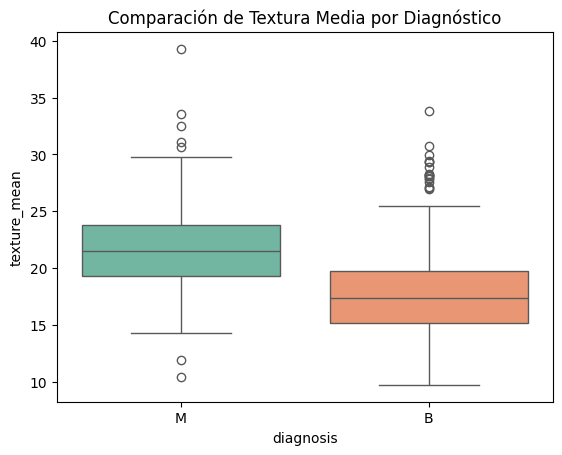

In [13]:
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

benign_texture = df[df['diagnosis'] == 'B']['texture_mean']
malignant_texture = df[df['diagnosis'] == 'M']['texture_mean']
t_stat, p_val = ttest_ind(benign_texture, malignant_texture)
print(f'Estadístico t: {t_stat:.2f}, Valor p: {p_val:.2e}')

# Visualización: Boxplot
sns.boxplot(x='diagnosis', y='texture_mean', data=df, palette='Set2')
plt.title('Comparación de Textura Media por Diagnóstico')
plt.show()

# Conclusiones del EDA
De acuerdo con las hipótesis planteadas en el análisis inicial:

- Los tumores malignos presentan mayores valores promedio de radio, área y
perímetro que los benignos.
Esta hipótesis se confirma fuertemente mediante las visualizaciones (boxplots y dispersión) y la comparación de medias en los insights adicionales. Las medias para tumores malignos son consistentemente más altas, lo que indica que estas variables son discriminantes clave.
- La variable concavity_worst es un buen predictor para diferenciar entre tipos de tumor: Apoyada por el violinplot y la tabla de medias, mostrando una clara separación.
- La textura media podría no variar significativamente entre tumores benignos y malignos: Esta hipótesis se rechaza basado en la prueba t-student, que indica una diferencia significativa. Aunque la dispersión en el scatterplot no muestra una separación obvia, estadísticamente sí hay variación.

En general, el dataset muestra patrones claros que permiten diferenciar tumores, alineándose con el objetivo de predecir diagnósticos mediante machine learning. Los insights adicionales confirman el desbalance moderado (más benignos) y destacan la redundancia en variables correlacionadas (radio, área, perímetro), sugiriendo posibles reducciones dimensionales para modelos futuros.

# Ingeniería de Atributos

Antes de avanzar con los modelos para evaluar, preparamos los datos:

- Definimos el target (diagnosis: M → 1, B → 0).
- Estandarizamos todas las variables numéricas.
- Creamos nuevas variables: ratios entre medidas (ej. radio/área, concavidad/compactness) para capturar relaciones.

In [14]:
# Ingeniería de atributos y preprocesamiento
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Target binario: 1 = maligno (M), 0 = benigno (B)
df['target'] = (df['diagnosis'] == 'M').astype(int)

# Variables (eliminamos id y diagnosis)
X = df.drop(['id', 'diagnosis', 'target'], axis=1)
y = df['target']

# Estandarización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Nuevas variables (ratios en escala original para interpretación)
X_scaled['radius_area_ratio_mean'] = df['radius_mean'] / df['area_mean']
X_scaled['radius_area_ratio_worst'] = df['radius_worst'] / df['area_worst']
X_scaled['concavity_compactness_ratio_worst'] = df['concavity_worst'] / (df['compactness_worst'] + 1e-6)  # evitar división por cero

# División estratificada (20% test, mantener proporción de clases)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

print("Proporción train/test:", X_train.shape, X_test.shape)
print("Proporción malignos en train:", y_train.mean().round(3))

Proporción train/test: (455, 33) (114, 33)
Proporción malignos en train: 0.374


# Entrenamiento y Testeo

Entrenamos 3 modelos:

- Regresión Logística
- Random Forest.
- XGBoost (suele destacar en datasets médicos).

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

results = {}
for name, model in models.items():
    # Validación cruzada
    scores = cross_validate(model, X_train, y_train, cv=cv,
                            scoring=['roc_auc', 'accuracy', 'precision', 'recall', 'f1'])
    results[name] = {k: v.mean().round(4) for k, v in scores.items() if 'test_' in k}

    # Entrenamiento final y evaluación en test
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name].update({
    'Test ROC AUC':   round(roc_auc_score(y_test, y_prob),   4),
    'Test Accuracy':  round(accuracy_score(y_test, y_pred),  4),
    'Test Recall':    round(recall_score(y_test, y_pred),    4),
    'Test F1':        round(f1_score(y_test, y_pred),        4)
})

# Mostrar resultados
pd.DataFrame(results).T

,test_roc_auc,test_accuracy,test_precision,test_recall,test_f1,Test ROC AUC,Test Accuracy,Test Recall,Test F1
Logistic Regression,0.9960,0.9736,0.9771,0.9529,0.9640,0.9964,0.9737,0.9286,0.963
Random Forest,0.9894,0.9582,0.9580,0.9294,0.9433,0.9962,0.9737,0.9286,0.963
XGBoost,0.9928,0.9648,0.9586,0.9471,0.9525,0.9914,0.9649,0.9048,0.950


# Optimización de Hiperparámetros

Optimizamos XGBoost con GridSearchCV

In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0]
}

grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid, cv=cv, scoring='roc_auc', n_jobs=-1
)
grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor ROC AUC en CV:", grid.best_score_.round(4))

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

print("\nEvaluación en test (XGBoost optimizado):")
print("ROC AUC:", round(roc_auc_score(y_test, y_prob_best),4))
print("Recall:", round(recall_score(y_test, y_pred_best),4))
print("F1:", round(f1_score(y_test, y_pred_best),4))

Mejores parámetros: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Mejor ROC AUC en CV: 0.9943

Evaluación en test (XGBoost optimizado):
ROC AUC: 0.9921
Recall: 0.881
F1: 0.9367


# Selección de Modelos e Interpretabilidad con SHAP

Usamos ROC AUC como métrica principal (útil para clasificación binaria). También Recall (sensibilidad a casos positivos = malignos).
Interpretamos el mejor modelo con SHAP (valores SHAP miden impacto de cada variable).

                   variable  mean_abs_shap
7       concave points_mean       0.974708
31  radius_area_ratio_worst       0.864936
13                  area_se       0.853830
21            texture_worst       0.843160
27     concave points_worst       0.842450
26          concavity_worst       0.806668
1              texture_mean       0.503209
15           compactness_se       0.447559
22          perimeter_worst       0.428651
4           smoothness_mean       0.362307


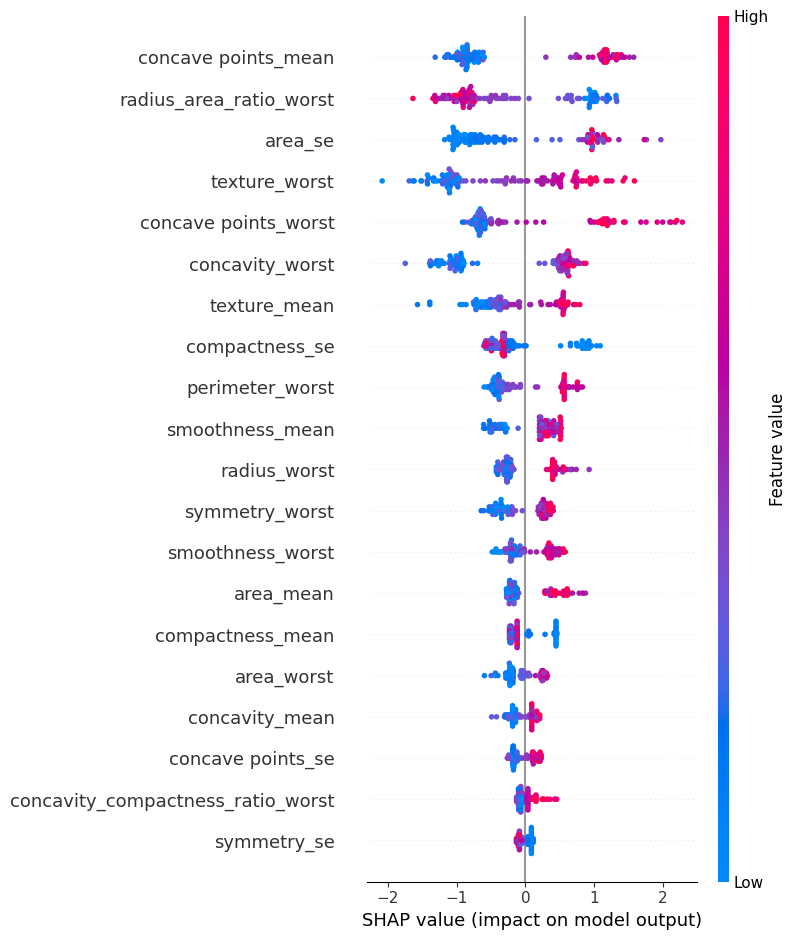

In [17]:
import shap
import numpy as np
import pandas as pd

# SHAP para el XGBoost optimizado
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Resumen global de importancia (beeswarm plot)
shap.summary_plot(shap_values, X_test, show=False)

# Importancia media absoluta
shap_importance = pd.DataFrame({
    'variable': X_test.columns,
    'mean_abs_shap': np.abs(shap_values).mean(0)
}).sort_values('mean_abs_shap', ascending=False)
print(shap_importance.head(10))

# Conclusión

Los tres modelos logran un rendimiento excelente, con ROC AUC > 0.98 en la mayoría de casos.

- El modelo de Regresión Logística es muy competitivo (simple, interpretable, AUC 0.99), ideal si se prioriza explicabilidad, dado que estamos prediciendo una variable dependiente binaria (maligno o benigno).
- Random Forest mejora ligeramente en precisión y maneja bien interacciones no lineales (AUC 0.99).
- XGBoost (optimizado): tiene un muy alto AUC (0.99) y robustez a ruido.

En cuanto a las hipótesis planteadas, se identifica que las variables más importantes para la detección de tumores malignos coinciden con las conclusiones realizadas en el análisis exploratorio de datos (EDA), como lo son la concavidad, radio, área y textura del tumor (demostrado en el análisis con SHAP). Esto valida que los tumores malignos tienen tamaños más irregulares y grandes.

De los modelos revisados, se recomienda usar XGBoost optimizado (mejor balance AUC/Recall). Si se necesita máxima interpretabilidad, usar Regresión Logistica. El dataset permite accuracies >97% y AUC casi perfectos, confirmando que es posible predecir con alta fiabilidad el diagnóstico a partir de estas medidas, por lo que es muy probable que se desarrolle cáncer de mama en mujeres cuyo estudio clínico revele tejido denso y abultado de un tamaño por sobre la media de la muestra, lo que implica que sea muy recomendable que las mujeres en caso de encontrarse un bulto extraño acudan al médico para ir evaluando su evolución, ya que a medida que crezca el tejido extraño, mayor es la probabilidad de desarrollar cáncer.

Por último es importante reconocer que interpretar un modelo de machine learning es una caja negra, por lo que es tarea del investigador poder utilizar bien dichas herramientas y sacar conclusiones, pues efectivamente son muy potentes en cuanto al poder predictivo que poseen, y en este caso de estudio permite desarrollar nuevas miras a la ciencia de datos en salud.